In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from utils import load_excel_sheets, process_benchmark_stats, aggregate_stats, global_model_list

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
dfs = load_excel_sheets('../data/PB1/P1B')

print("\nLoaded dataframe keys:", list(dfs.keys()))

 Loaded: Gemini 2.0_t.xlsx Sheets:[3/3]
 Loaded: DeepSeek-V3_t.xlsx Sheets:[3/3]
 Loaded: ChatGPT-4o_t.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o1_t.xlsx Sheets:[3/3]
 Loaded: Gemini 1.5_t.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o3_t.xlsx Sheets:[3/3]

Loaded dataframe keys: ['P1B_Gemini 2.0_CM', 'P1B_Gemini 2.0_EM', 'P1B_Gemini 2.0_QM', 'P1B_DeepSeek-V3_CM', 'P1B_DeepSeek-V3_EM', 'P1B_DeepSeek-V3_QM', 'P1B_ChatGPT-4o_CM', 'P1B_ChatGPT-4o_EM', 'P1B_ChatGPT-4o_QM', 'P1B_ChatGPT-o1_CM', 'P1B_ChatGPT-o1_EM', 'P1B_ChatGPT-o1_QM', 'P1B_Gemini 1.5_CM', 'P1B_Gemini 1.5_EM', 'P1B_Gemini 1.5_QM', 'P1B_ChatGPT-o3_CM', 'P1B_ChatGPT-o3_EM', 'P1B_ChatGPT-o3_QM']


In [9]:
process_benchmark_stats(dfs)
# Verify the result with the first dataframe
if dfs:
    first_key = list(dfs.keys())[0]
    print(f"\nFirst 5 rows of {first_key}:")
    display(dfs[first_key].head())

Processing DataFrames: 100%|██████████| 18/18 [00:00<00:00, 767.75it/s]


First 5 rows of P1B_Gemini 2.0_CM:


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
0,1,6,6,6,6,P1B,Gemini 2.0,CM,P1B_Gemini 2.0_CM,6.0,0.0,100.000000,0.0
1,2,9,9,9,9,P1B,Gemini 2.0,CM,P1B_Gemini 2.0_CM,9.0,0.0,100.000000,0.0
2,3,13,10,10,10,P1B,Gemini 2.0,CM,P1B_Gemini 2.0_CM,10.0,0.0,76.923077,0.0
3,4,10,10,10,10,P1B,Gemini 2.0,CM,P1B_Gemini 2.0_CM,10.0,0.0,100.000000,0.0
4,5,7,7,7,7,P1B,Gemini 2.0,CM,P1B_Gemini 2.0_CM,7.0,0.0,100.000000,0.0


In [10]:
# Create master df and summary df for plotting
master_df, summary_stats = aggregate_stats(dfs)

display(master_df.head())
display(summary_stats.head())

/Users/jonah/Github - Projects/LLM Project paper/AI-in-Physics-in-Education-j/Plot code/utils.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = master_df.groupby(['Dir', 'Model', 'Sheet']).agg(


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
36,1,6,5,5,5,P1B,ChatGPT-4o,CM,P1B_ChatGPT-4o_CM,5.0,0.000000,83.333333,0.000000
37,2,9,9,9,3,P1B,ChatGPT-4o,CM,P1B_ChatGPT-4o_CM,7.0,3.464102,77.777778,38.490018
38,3,13,11,13,9,P1B,ChatGPT-4o,CM,P1B_ChatGPT-4o_CM,11.0,2.000000,84.615385,15.384615
39,4,10,6,6,6,P1B,ChatGPT-4o,CM,P1B_ChatGPT-4o_CM,6.0,0.000000,60.000000,0.000000
40,5,7,7,7,7,P1B,ChatGPT-4o,CM,P1B_ChatGPT-4o_CM,7.0,0.000000,100.000000,0.000000


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1B,ChatGPT-4o,CM,83.018868,15.013610,6.129281
1,P1B,ChatGPT-4o,EM,58.503401,37.007453,15.108229
2,P1B,ChatGPT-4o,QM,87.005650,10.728726,4.379984
3,P1B,Gemini 1.5,CM,85.534591,15.470081,6.315634
4,P1B,Gemini 1.5,EM,75.510204,31.614306,12.906486


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1B,ChatGPT-4o,CM,83.018868,15.013610,6.129281
3,P1B,Gemini 1.5,CM,85.534591,15.470081,6.315634
6,P1B,ChatGPT-o1,CM,91.194969,11.082639,4.524469
9,P1B,Gemini 2.0,CM,94.339623,9.421114,3.846154
12,P1B,DeepSeek-V3,CM,96.226415,6.280743,2.564103
15,P1B,ChatGPT-o3,CM,98.742138,2.093581,0.854701


Dirs: ['P1B']
Sheets: ['CM' 'EM' 'QM']


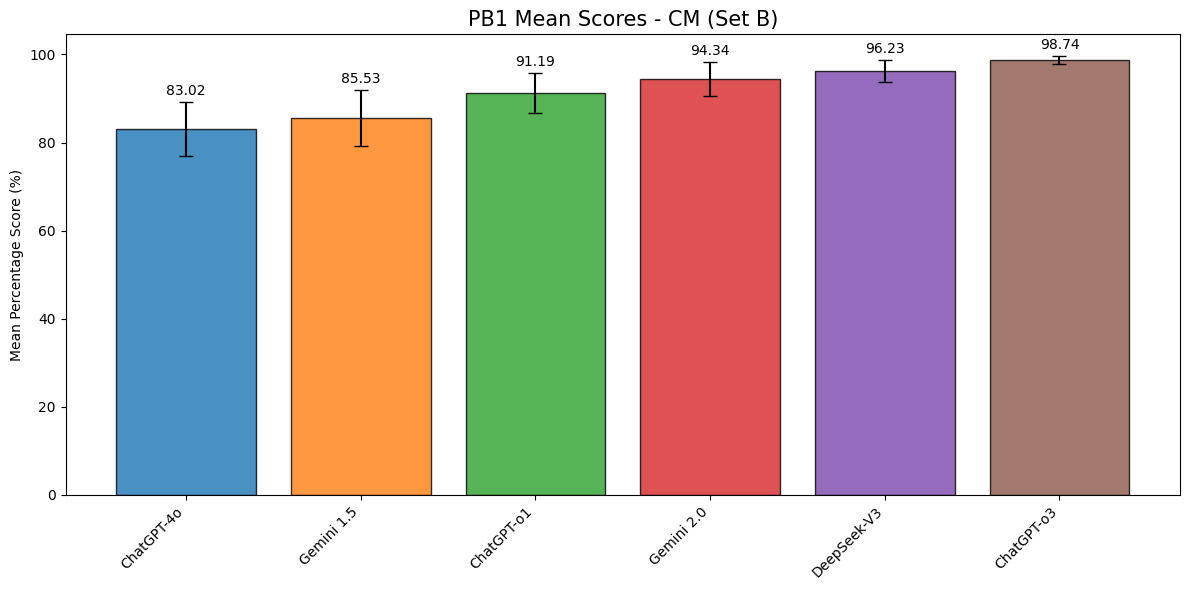

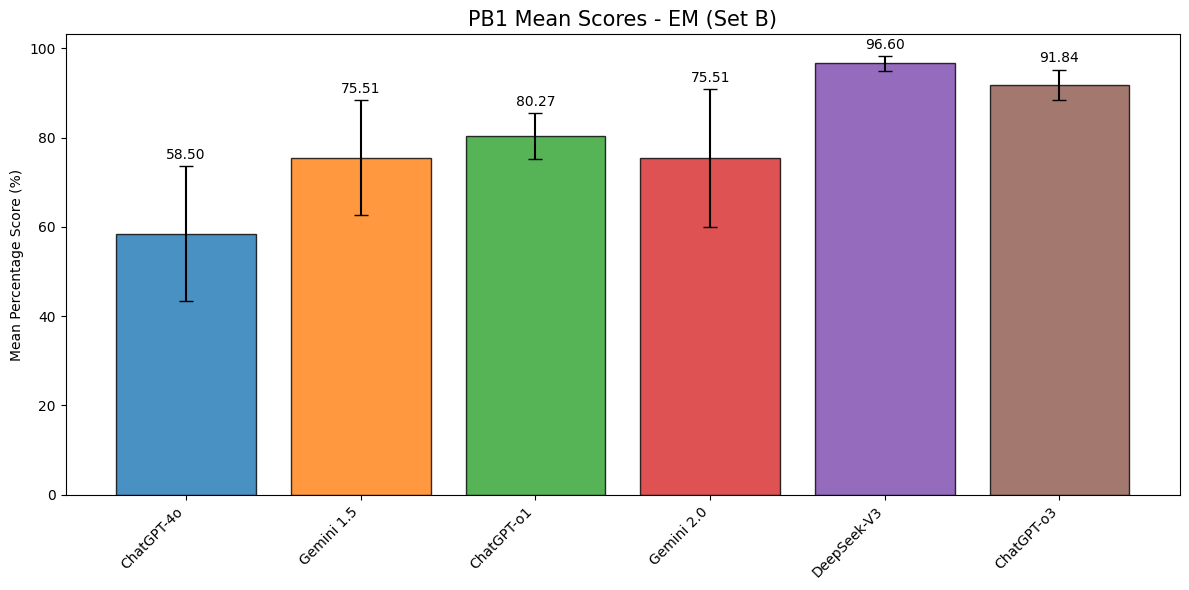

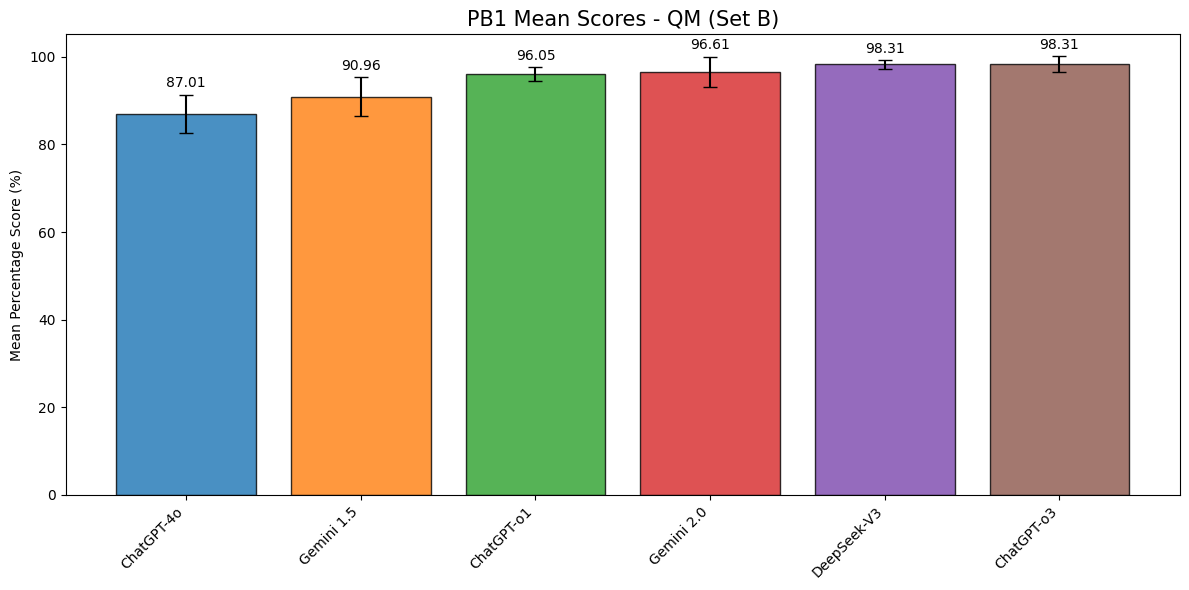

In [16]:
# Get relevant models
unique_models = master_df['Model'].unique()
model_list = [model for model in global_model_list if model in unique_models]
topic_sheet_df = summary_stats.groupby(['Dir','Sheet'])

display(topic_sheet_df.get_group(('P1B', 'CM')))

# Get unique dirs and sheets for plotting
dir_list = master_df['Dir'].unique()
sheet_list = master_df['Sheet'].unique()

print("Dirs:", dir_list)
print("Sheets:", sheet_list)

# Colors
colors = ["#1b75b5", '#ff7f0e', '#2ca02c', '#d62728', "#7b46ad", '#8c564b']
safe_colors = (colors * 3) 

for dir in dir_list:
    for sheet in sheet_list:
        # Extract data
        try:
            group = topic_sheet_df.get_group((dir, sheet))
        except KeyError:
            continue # Skip completely if this Dir/Sheet combo doesn't exist
            
        group = group.dropna(subset=['Total_Mean%'])
        
        # If dropping the missing models leaves the group completely empty, skip plotting
        if group.empty:
            continue

        # 1. Grab the exact models and stats present in THIS specific group
        current_models = group['Model']
        means = group['Total_Mean%']
        std_errs = group['Total_Std_error%']

        # Set up plot
        fig, ax = plt.subplots(figsize=(12, 6))

        # 2. Set X to match the actual number of rows left in the group
        x = np.arange(len(current_models)) 
        
        # 3. Slice the colors to match the exact number of bars
        current_colors = safe_colors[:len(x)]
        
        # Plotting
        rects1 = ax.bar(x, means, width=0.8, yerr=std_errs, 
                        capsize=5, color=current_colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel('Mean Percentage Score (%)')
        ax.set_title(f'PB1 Mean Scores - {sheet} (Set B)', fontsize=15)
        ax.set_xticks(x)
        
        # 4. Use the current_models for the labels so they align perfectly
        ax.set_xticklabels(current_models, rotation=45, ha='right')

        # Add labels 
        ax.bar_label(rects1, padding=3, fmt='%.2f')

        # Save figure
        output_dir = '../Plots/Bar_Charts'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'PB1_B_{sheet}_Bar_Chart.png'), dpi=300, bbox_inches='tight')
        plt.tight_layout()
        plt.show()

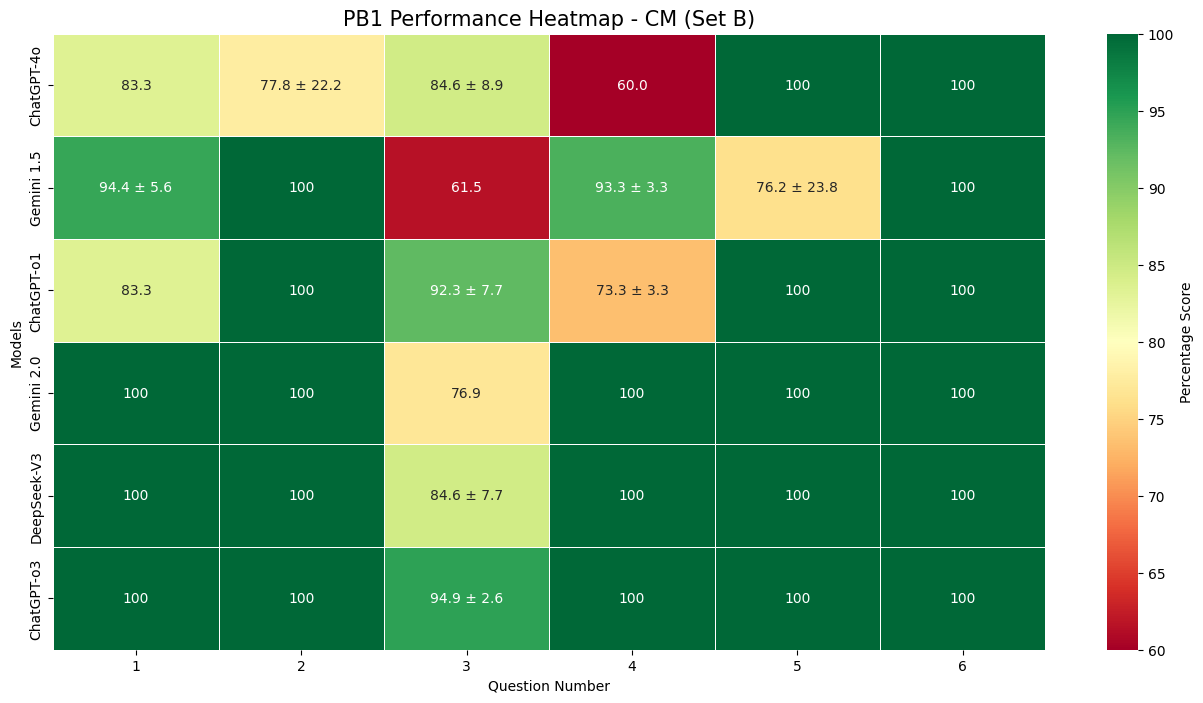

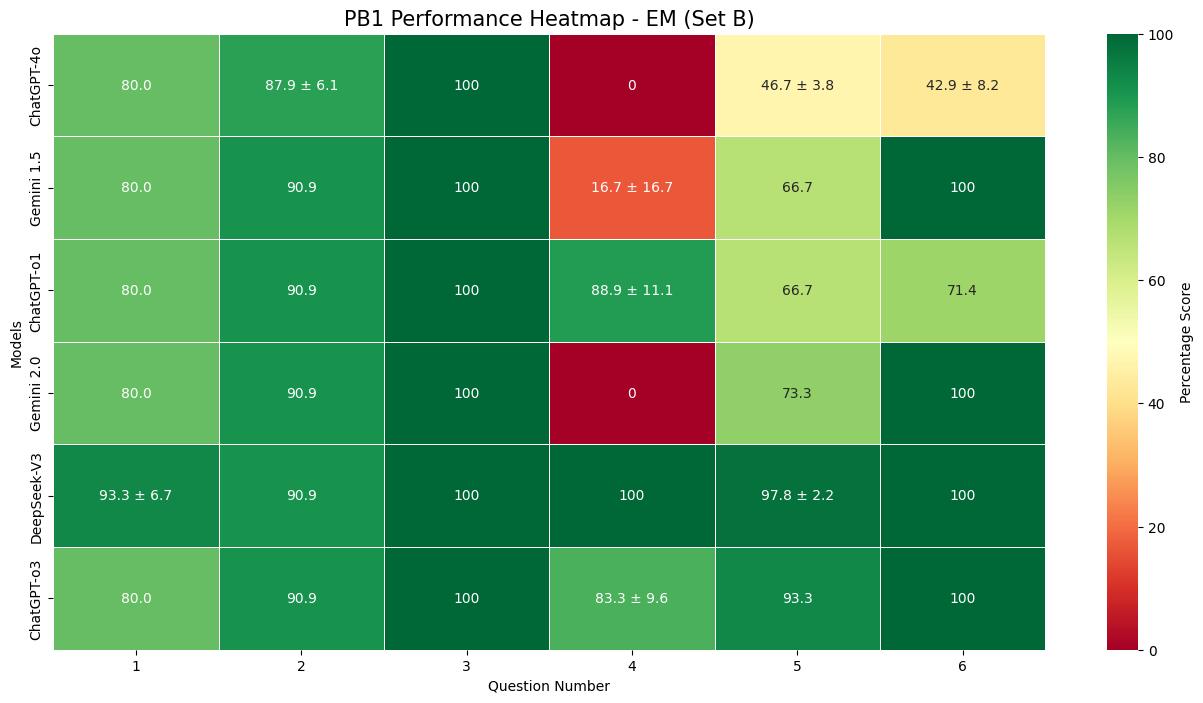

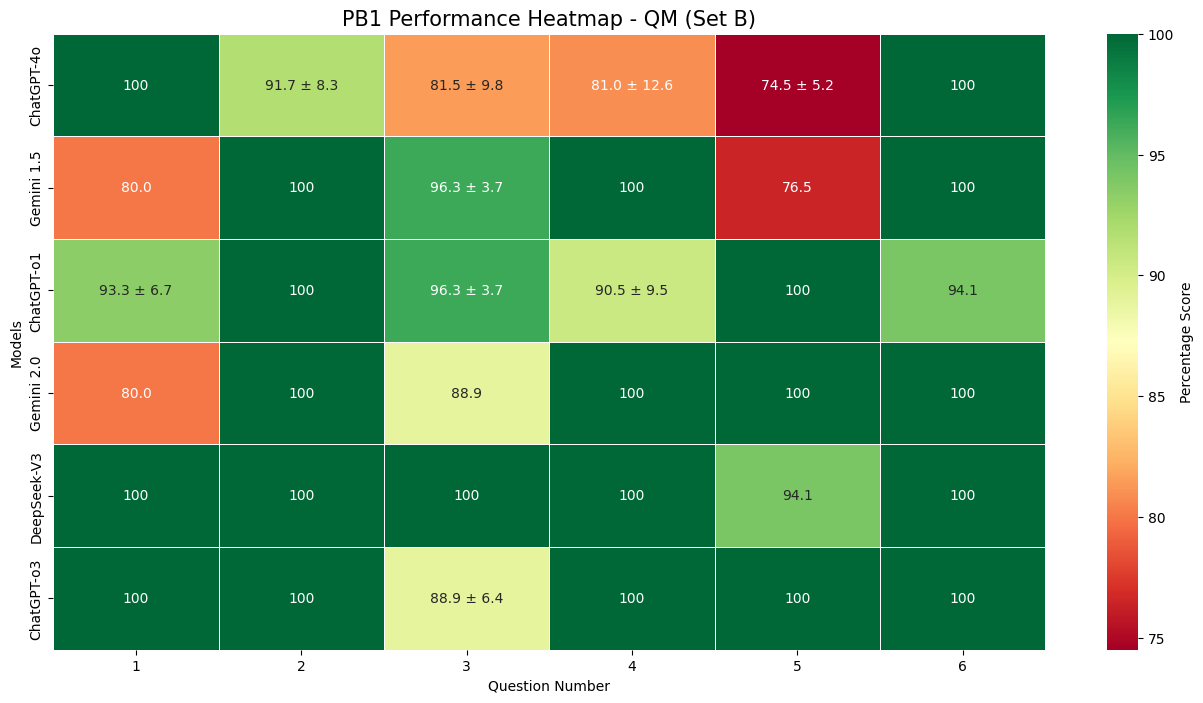

In [17]:
# Heat map
# Rows - Models
# Cols - Questions

topic_sheet_df = master_df.groupby(['Dir','Sheet'])

# Plot
for dir in dir_list:
    for sheet in sheet_list:
        target_group = topic_sheet_df.get_group((dir, sheet))

        # Get heatmap matrix
        heatmap_matrix = target_group.pivot(index='Model', columns='Question Number', values='mean percentage mark')
        heatmap_matrix_std = target_group.pivot(index='Model', columns='Question Number', values='std percentage') 
        heatmap_matrix_se = heatmap_matrix_std / np.sqrt(3) 

        # Create an empty array for our clean annotations
        annot_labels = np.empty(heatmap_matrix.shape, dtype=object)
        
        # Loop through and apply formatting rules
        for i in range(heatmap_matrix.shape[0]):
            for j in range(heatmap_matrix.shape[1]):
                mean = heatmap_matrix.values[i, j]
                se = heatmap_matrix_se.values[i, j]
                
                # If standard error is effectively 0 (covers 100%, 0%, and perfectly consistent runs)
                if round(se, 1) == 0.0:
                    # Drop the decimal completely for 100 and 0 to save even more space
                    if mean == 100.0 or mean == 0.0:
                        annot_labels[i, j] = f"{mean:.0f}" 
                    else:
                        annot_labels[i, j] = f"{mean:.1f}"
                # Otherwise, print Mean ± SE
                else:
                    annot_labels[i, j] = f"{mean:.1f} ± {se:.1f}"

        plt.figure(figsize=(16, 8))
        sns.heatmap(heatmap_matrix, 
                    annot=annot_labels,    
                    fmt="",                
                    cmap='RdYlGn',         
                    linewidths=0.5,        
                    cbar_kws={'label': 'Percentage Score'})

        plt.title(f'PB1 Performance Heatmap - {sheet} (Set B)', fontsize=15)
        plt.ylabel('Models')
        plt.xlabel('Question Number')

         # Save figure
        output_dir = '../Plots/Heat_Maps'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'PB1_B_{sheet}_Heat_Map.png'), dpi=300, bbox_inches='tight')
       
        plt.show()


# Set B graphs

In [ ]:
# Set up mask for each topic
CM_Qs = np.array([2, 5, 7, 8, 9, 10])
QM_Qs = np.array([1, 2, 3, 5, 6, 9])
EM_Qs = np.array([2, 4, 6, 7, 9, 10])

,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,P1,ChatGPT-4o,CM,85.223368,15.242674,4.820157
3,P1,Gemini 1.5,CM,85.223368,14.020538,4.433683
6,P1,ChatGPT-o1,CM,90.378007,11.013385,3.482738
9,P1,Gemini 2.0,CM,94.845361,7.903745,2.499384
12,P1,DeepSeek-V3,CM,97.938144,4.865043,1.538462
15,P1,ChatGPT-o3,CM,98.969072,1.681208,0.531645


Dirs: ['P1']
Sheets: ['CM' 'EM' 'QM']

RESULTS FOR: P1 - CM
      Model  Mean (%)  Std Error (%)
 ChatGPT-4o     85.22           4.82
 Gemini 1.5     85.22           4.43
 ChatGPT-o1     90.38           3.48
 Gemini 2.0     94.85           2.50
DeepSeek-V3     97.94           1.54
 ChatGPT-o3     98.97           0.53

--- Highlights ---
Overall Average (All Models): 92.10%
Top Performer:                ChatGPT-o3 (98.97%)
Lowest Performer:             ChatGPT-4o (85.22%)
--------------------------------------------------


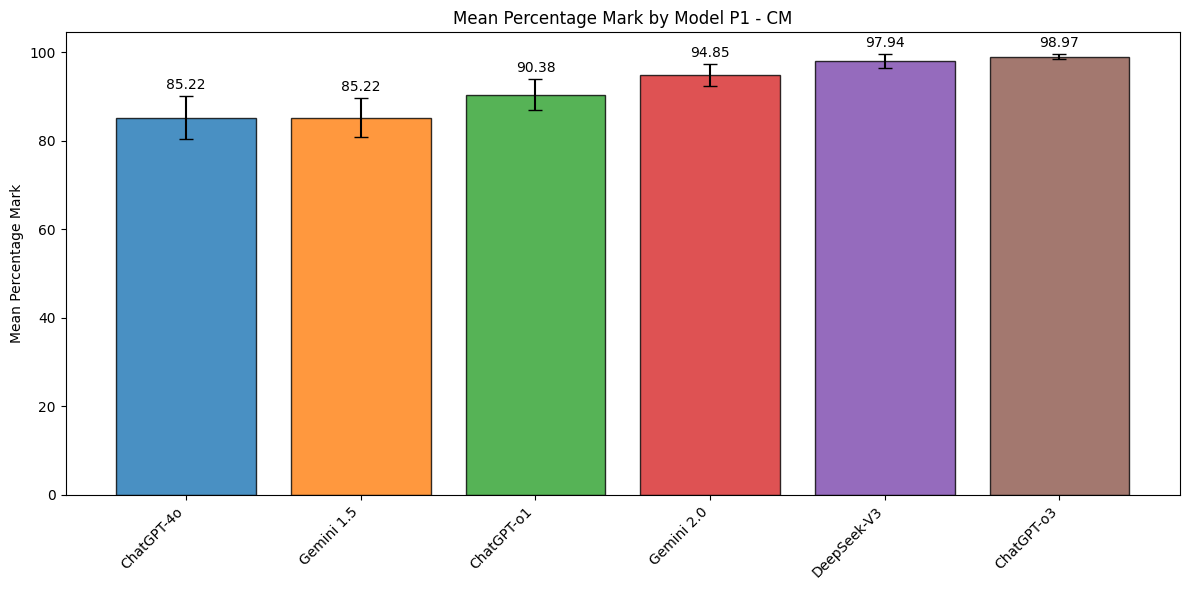


RESULTS FOR: P1 - EM
      Model  Mean (%)  Std Error (%)
 ChatGPT-4o     55.68          10.97
 Gemini 1.5     74.62          10.75
 ChatGPT-o1     77.65           8.50
 Gemini 2.0     75.76          11.83
DeepSeek-V3     89.02           6.15
 ChatGPT-o3     90.53           2.30

--- Highlights ---
Overall Average (All Models): 77.21%
Top Performer:                ChatGPT-o3 (90.53%)
Lowest Performer:             ChatGPT-4o (55.68%)
--------------------------------------------------


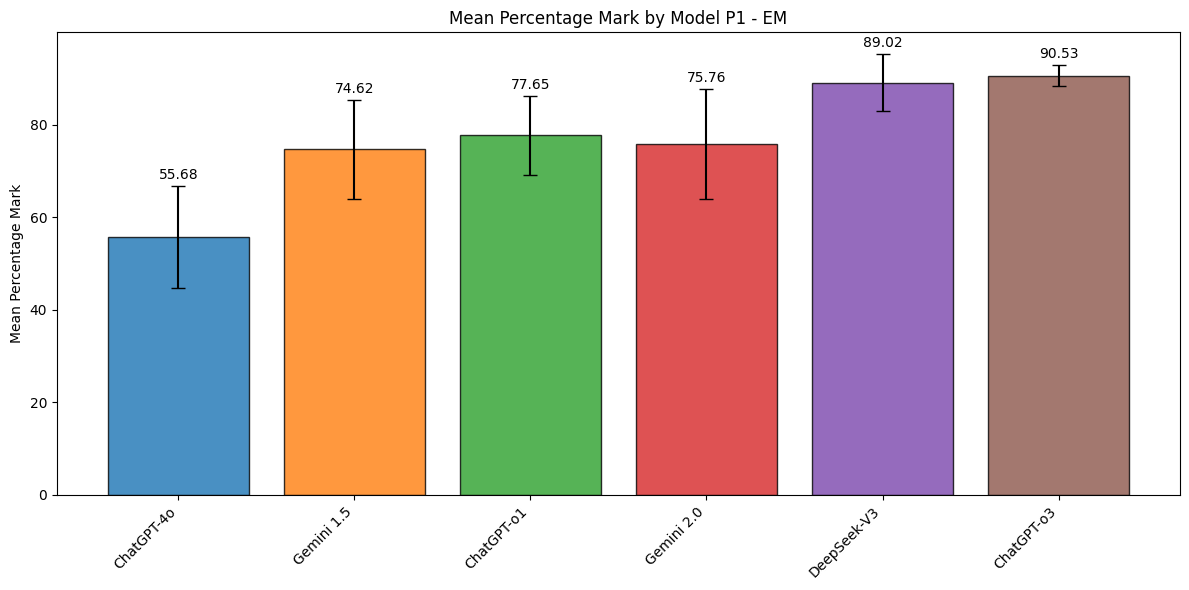


RESULTS FOR: P1 - QM
      Model  Mean (%)  Std Error (%)
 ChatGPT-4o     85.12           3.44
 Gemini 1.5     87.50           5.65
 ChatGPT-o1     95.24           1.93
 Gemini 2.0     98.21           2.18
DeepSeek-V3     98.51           0.64
 ChatGPT-o3     98.81           1.11

--- Highlights ---
Overall Average (All Models): 93.90%
Top Performer:                ChatGPT-o3 (98.81%)
Lowest Performer:             ChatGPT-4o (85.12%)
--------------------------------------------------


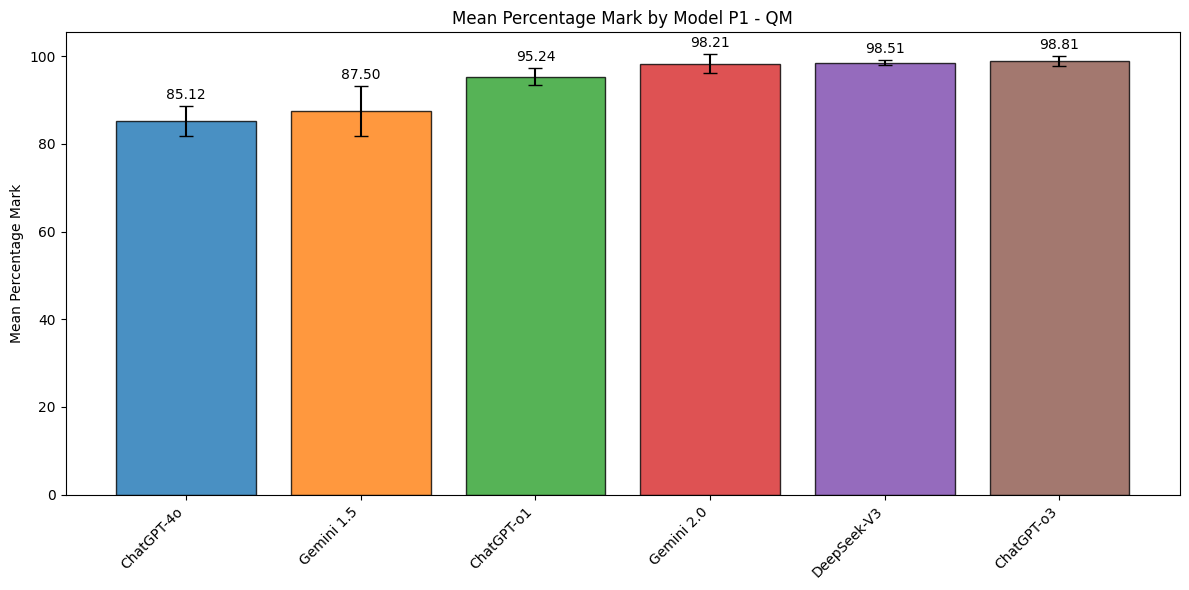

In [8]:
# Get relevant models
unique_models = master_df['Model'].unique()
model_list = [model for model in global_model_list if model in unique_models]
topic_sheet_df = summary_stats.groupby(['Dir','Sheet'])

display(topic_sheet_df.get_group(('P1', 'CM')))

# Get unique dirs and sheets for plotting
dir_list = master_df['Dir'].unique()
sheet_list = master_df['Sheet'].unique()

print("Dirs:", dir_list)
print("Sheets:", sheet_list)

# Colors
colors = ["#1b75b5", '#ff7f0e', '#2ca02c', '#d62728', "#7b46ad", '#8c564b']
safe_colors = (colors * 3) 

for dir in dir_list:
    for sheet in sheet_list:
        # Extract data
        try:
            group = topic_sheet_df.get_group((dir, sheet))
        except KeyError:
            continue # Skip completely if this Dir/Sheet combo doesn't exist
            
        group = group.dropna(subset=['Total_Mean%'])
        
        # If dropping the missing models leaves the group completely empty, skip plotting
        if group.empty:
            continue

        # 1. Grab the exact models and stats present in THIS specific group
        current_models = group['Model']
        means = group['Total_Mean%']
        std_errs = group['Total_Std_error%']

        # ==========================================
        print(f"\n{'='*50}")
        print(f"RESULTS FOR: {dir} - {sheet}")
        print(f"{'='*50}")
        
        # Print a clean table of the data going into the plot
        summary_table = group[['Model', 'Total_Mean%', 'Total_Std_error%']].copy()
        # Rename columns slightly for a cleaner printout if desired
        summary_table.columns = ['Model', 'Mean (%)', 'Std Error (%)']
        print(summary_table.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
        
        # Calculate overall useful metrics
        overall_mean = means.mean()
        best_model = group.loc[group['Total_Mean%'].idxmax(), 'Model']
        best_score = group['Total_Mean%'].max()
        worst_model = group.loc[group['Total_Mean%'].idxmin(), 'Model']
        worst_score = group['Total_Mean%'].min()

        print("\n--- Highlights ---")
        print(f"Overall Average (All Models): {overall_mean:.2f}%")
        print(f"Top Performer:                {best_model} ({best_score:.2f}%)")
        print(f"Lowest Performer:             {worst_model} ({worst_score:.2f}%)")
        print("-" * 50)
        # ==========================================

        # Set up plot
        fig, ax = plt.subplots(figsize=(12, 6))

        # 2. Set X to match the actual number of rows left in the group
        x = np.arange(len(current_models)) 
        
        # 3. Slice the colors to match the exact number of bars
        current_colors = safe_colors[:len(x)]
        
        # Plotting
        rects1 = ax.bar(x, means, width=0.8, yerr=std_errs, 
                        capsize=5, color=current_colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel('Mean Percentage Mark')
        ax.set_title(f'Mean Percentage Mark by Model {dir} - {sheet}')
        ax.set_xticks(x)
        
        # 4. Use the current_models for the labels so they align perfectly
        ax.set_xticklabels(current_models, rotation=45, ha='right')

        # Add labels 
        ax.bar_label(rects1, padding=3, fmt='%.2f')

        plt.tight_layout()
        plt.show()